In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the file
df = pd.read_csv('household_power_consumption.txt',
                  sep=';',
                  parse_dates={'DateTime': ['Date', 'Time']},
                  dayfirst=True,
                  low_memory=False,
                  na_values=['?'])

# Fill missing values with column average
df.fillna(df.mean(numeric_only=True), inplace=True)

# Extract date and time features
df['Date']   = df['DateTime'].dt.date
df['Hour']   = df['DateTime'].dt.hour
df['Month']  = df['DateTime'].dt.month
df['Year']   = df['DateTime'].dt.year
df['Weekday']= df['DateTime'].dt.weekday

# Confirm
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print(df.head())

C:\Users\rkxx\AppData\Local\Temp\ipykernel_51736\1325404959.py:6: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('household_power_consumption.txt',


Shape: (2075259, 13)
Missing values: 0
             DateTime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
0              18.4             0.0             1.0            17.0   
1              23.0             0.0             1.0            16.0   
2              23.0             0.0             2.0            17.0   
3              23.0             0.0             1.0            17.0   
4              15.8             0.0             1.0            17.0   

         Date  Hour  Month  Year  Weekday  
0  2006-12-16    17  

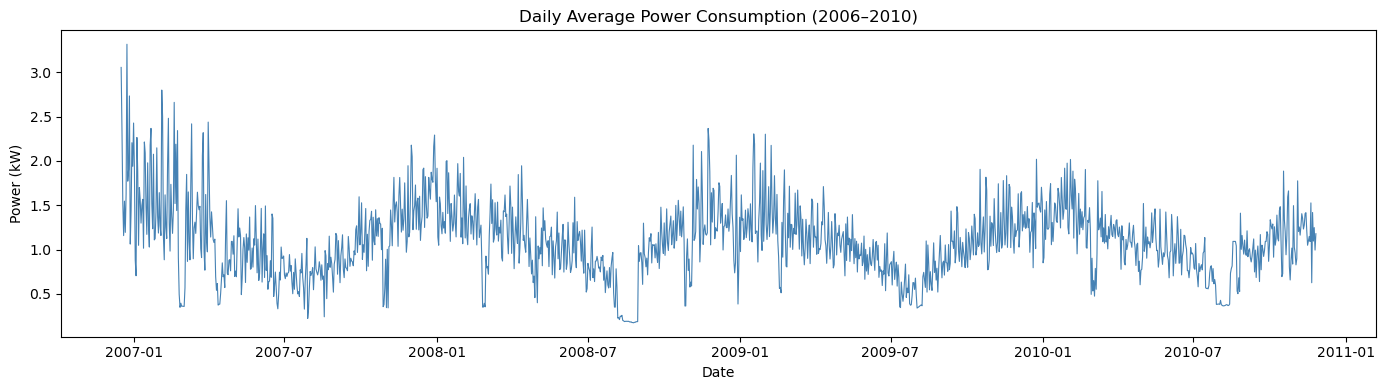

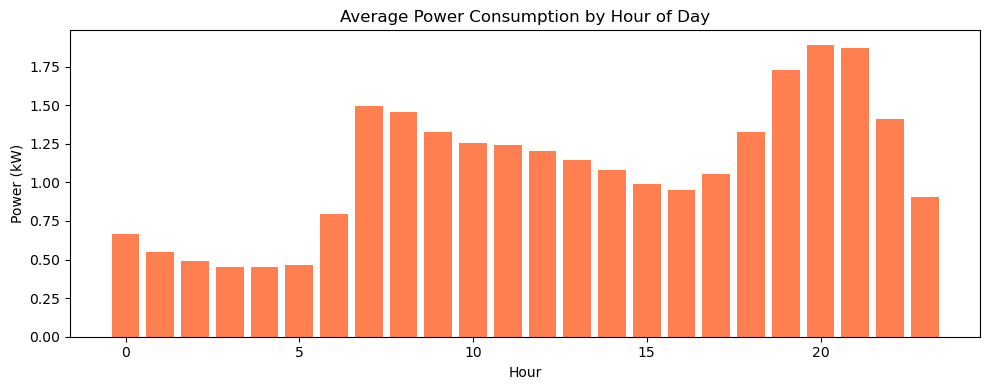

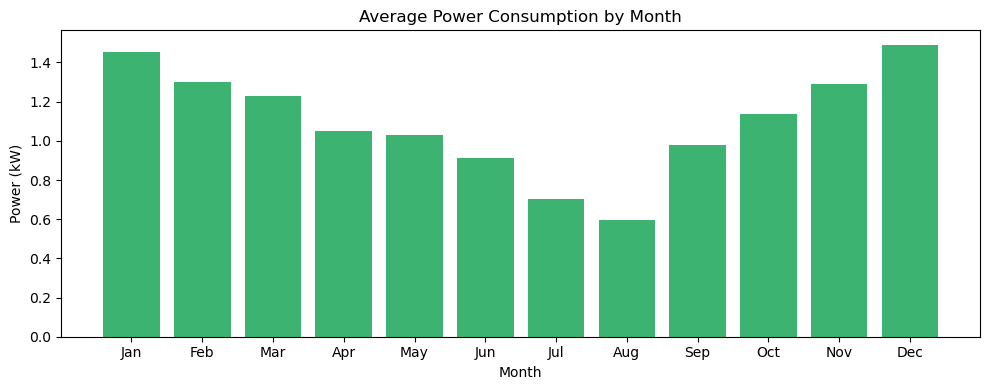

In [2]:
# Graph 1 — Daily average consumption over 4 years
daily_avg = df.groupby('Date')['Global_active_power'].mean()

plt.figure(figsize=(14, 4))
plt.plot(daily_avg.index, daily_avg.values, color='steelblue', linewidth=0.8)
plt.title('Daily Average Power Consumption (2006–2010)')
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.tight_layout()
plt.show()

# Graph 2 — Average consumption by hour of day
hourly_avg = df.groupby('Hour')['Global_active_power'].mean()

plt.figure(figsize=(10, 4))
plt.bar(hourly_avg.index, hourly_avg.values, color='coral')
plt.title('Average Power Consumption by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Power (kW)')
plt.tight_layout()
plt.show()

# Graph 3 — Average consumption by month
monthly_avg = df.groupby('Month')['Global_active_power'].mean()

plt.figure(figsize=(10, 4))
plt.bar(monthly_avg.index, monthly_avg.values, color='mediumseagreen')
plt.title('Average Power Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Power (kW)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

=== Simple Linear Regression ===
R² Score : 0.0118
RMSE     : 0.4140
Slope    : -0.000109
Meaning  : Power decreases over time


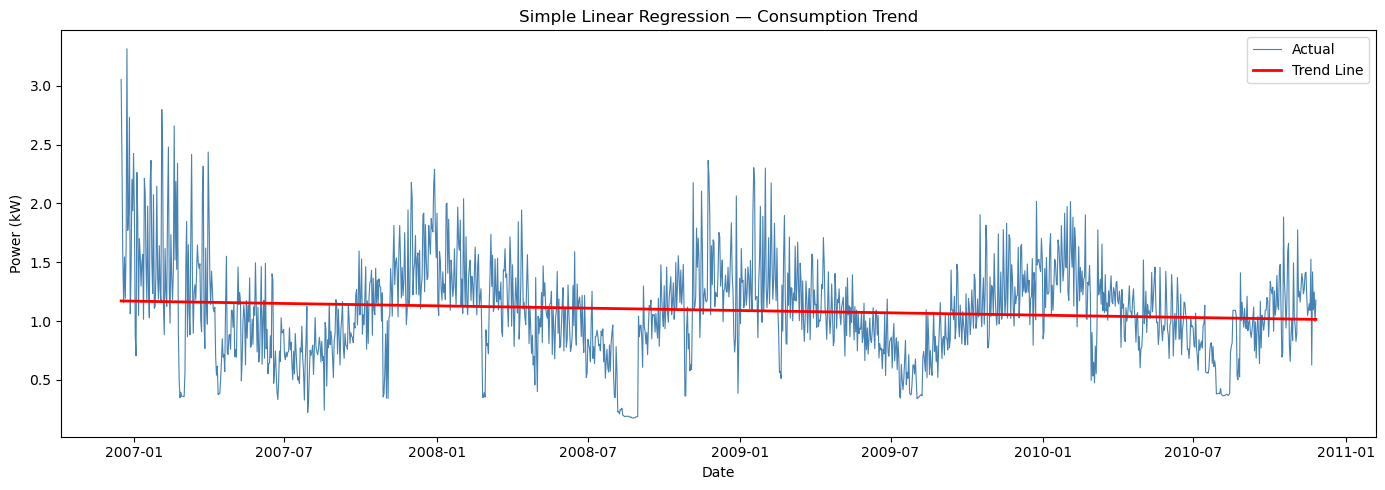

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Prepare data
daily_avg_df = daily_avg.reset_index()
daily_avg_df.columns = ['Date', 'Avg_Power']
daily_avg_df['Day_Number'] = range(len(daily_avg_df))

X_slr = daily_avg_df[['Day_Number']]
y_slr = daily_avg_df['Avg_Power']

# Train model
slr = LinearRegression()
slr.fit(X_slr, y_slr)

# Predict
y_slr_pred = slr.predict(X_slr)

# Results
print("=== Simple Linear Regression ===")
print(f"R² Score : {r2_score(y_slr, y_slr_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_slr, y_slr_pred)):.4f}")
print(f"Slope    : {slr.coef_[0]:.6f}")
print(f"Meaning  : Power {'increases' if slr.coef_[0] > 0 else 'decreases'} over time")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(daily_avg_df['Date'], y_slr.values,
         color='steelblue', linewidth=0.8, label='Actual')
plt.plot(daily_avg_df['Date'], y_slr_pred,
         color='red', linewidth=2, label='Trend Line')
plt.title('Simple Linear Regression — Consumption Trend')
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# Features
features = ['Voltage', 'Global_intensity',
            'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

X_mlr = df[features]
y_mlr = df['Global_active_power']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_mlr, y_mlr, test_size=0.2, random_state=42)

# Train model
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Predict
y_mlr_pred = mlr.predict(X_test)

# Results
print("=== Multiple Linear Regression ===")
print(f"R² Score : {r2_score(y_test, y_mlr_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_mlr_pred)):.4f}")

print("\nFeature Coefficients:")
for feat, coef in zip(features, mlr.coef_):
    print(f"  {feat:25s}: {coef:.4f}")

# Save predictions back to df for anomaly detection
df['Expected_Power'] = mlr.predict(X_mlr)
df['Deviation']      = df['Global_active_power'] - df['Expected_Power']

print("\nDeviation column added ✅")

=== Multiple Linear Regression ===
R² Score : 0.9982
RMSE     : 0.0446

Feature Coefficients:
  Voltage                  : 0.0045
  Global_intensity         : 0.2363
  Sub_metering_1           : -0.0002
  Sub_metering_2           : -0.0004
  Sub_metering_3           : 0.0025

Deviation column added ✅


In [8]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Updated label function — thresholds adjusted to actual data range
def label_anomaly(row):
    if row['Deviation'] < -0.3 and row['Global_reactive_power'] < 0.1:
        return 'Theft'        # Deviation strongly negative + low reactive power
    elif row['Voltage'] < 220 or row['Voltage'] > 245:
        return 'Fault'        # Voltage out of normal range
    elif row['Deviation'] > 0.1:
        return 'Surge'        # Consumption higher than expected
    else:
        return 'Normal'

df['Anomaly_Label'] = df.apply(label_anomaly, axis=1)

# Check label distribution
print("Label Distribution:")
print(df['Anomaly_Label'].value_counts())
print("\nPercentage:")
print(df['Anomaly_Label'].value_counts(normalize=True).mul(100).round(2))

# Prepare features
features_dt = ['Global_active_power', 'Global_reactive_power',
                'Voltage', 'Global_intensity', 'Deviation']

X_dt = df[features_dt]
y_dt = df['Anomaly_Label']

# Split 80/20
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42)

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_dt, y_train_dt)

# Evaluate
y_dt_pred = dt.predict(X_test_dt)
print("\n=== Decision Tree Results ===")
print(classification_report(y_test_dt, y_dt_pred))

# Show tree rules
print("\nDecision Tree Rules:")
print(export_text(dt, feature_names=features_dt))

Label Distribution:
Anomaly_Label
Normal    1892208
Fault      174627
Surge        6933
Theft        1491
Name: count, dtype: int64

Percentage:
Anomaly_Label
Normal    91.18
Fault      8.41
Surge      0.33
Theft      0.07
Name: proportion, dtype: float64

=== Decision Tree Results ===
              precision    recall  f1-score   support

       Fault       1.00      1.00      1.00     34852
      Normal       1.00      1.00      1.00    378532
       Surge       1.00      1.00      1.00      1372
       Theft       1.00      1.00      1.00       296

    accuracy                           1.00    415052
   macro avg       1.00      1.00      1.00    415052
weighted avg       1.00      1.00      1.00    415052


Decision Tree Rules:
|--- Voltage <= 245.00
|   |--- Deviation <= 0.10
|   |   |--- Deviation <= -0.30
|   |   |   |--- Global_reactive_power <= 0.10
|   |   |   |   |--- class: Theft
|   |   |   |--- Global_reactive_power >  0.10
|   |   |   |   |--- class: Normal
|   |   |--

In [9]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Binary classification — Theft vs Not Theft
df['Is_Theft'] = (df['Anomaly_Label'] == 'Theft').astype(int)

# Separate theft and normal rows
theft_rows  = df[df['Is_Theft'] == 1]
normal_rows = df[df['Is_Theft'] == 0]

print(f"Total Theft rows  : {len(theft_rows)}")
print(f"Total Normal rows : {len(normal_rows)}")

# Take ALL theft rows + 9000 normal rows
df_sample = pd.concat([
    theft_rows,
    normal_rows.sample(n=9000, random_state=42)
])

# Shuffle the sample
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nSample distribution:")
print(df_sample['Is_Theft'].value_counts())

# Features
features_svm = ['Global_active_power', 'Global_reactive_power',
                 'Voltage', 'Deviation']

X_svm = df_sample[features_svm]
y_svm = df_sample['Is_Theft']

# Scale features
scaler = StandardScaler()
X_svm_scaled = scaler.fit_transform(X_svm)

# Split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm_scaled, y_svm, test_size=0.2, random_state=42)

# Train SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_svm, y_train_svm)

# Evaluate
y_svm_pred = svm.predict(X_test_svm)
print("\n=== SVM Results ===")
print(classification_report(y_test_svm, y_svm_pred))

# Theft probability on 5 samples
print("\nTheft Probability on 5 Random Samples:")
sample_5 = X_test_svm[:5]
proba_5  = svm.predict_proba(sample_5)
actual_5 = y_test_svm.values[:5]

for i, (prob, actual) in enumerate(zip(proba_5, actual_5)):
    theft_prob = prob[1] * 100
    label      = "🚨 THEFT" if theft_prob > 50 else "✅ Normal"
    print(f"  Sample {i+1}: {theft_prob:.1f}% theft probability → {label} (Actual: {'Theft' if actual else 'Normal'})")

Total Theft rows  : 1491
Total Normal rows : 2073768

Sample distribution:
Is_Theft
0    9000
1    1491
Name: count, dtype: int64

=== SVM Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1810
           1       0.99      1.00      0.99       289

    accuracy                           1.00      2099
   macro avg       0.99      1.00      1.00      2099
weighted avg       1.00      1.00      1.00      2099


Theft Probability on 5 Random Samples:
  Sample 1: 0.0% theft probability → ✅ Normal (Actual: Normal)
  Sample 2: 100.0% theft probability → 🚨 THEFT (Actual: Theft)
  Sample 3: 0.2% theft probability → ✅ Normal (Actual: Normal)
  Sample 4: 0.0% theft probability → ✅ Normal (Actual: Normal)
  Sample 5: 0.0% theft probability → ✅ Normal (Actual: Normal)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Features for Random Forest
features_rf = ['Global_active_power', 'Global_reactive_power',
                'Voltage', 'Global_intensity', 'Deviation',
                'Hour', 'Month', 'Weekday']

X_rf = df[features_rf]
y_rf = df['Anomaly_Label']

# Split 80/20
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42)

print(f"Training rows : {X_train_rf.shape[0]:,}")
print(f"Testing rows  : {X_test_rf.shape[0]:,}")

# Train Random Forest — 100 trees
print("\nTraining Random Forest... (may take 1-2 mins)")
rf = RandomForestClassifier(n_estimators=100,
                             max_depth=10,
                             random_state=42,
                             n_jobs=-1)
rf.fit(X_train_rf, y_train_rf)
print("Training done! ✅")

# Evaluate
y_rf_pred = rf.predict(X_test_rf)
print("\n=== Random Forest Results ===")
print(classification_report(y_test_rf, y_rf_pred))

# Feature importance
print("\nFeature Importance (what matters most):")
for feat, imp in sorted(zip(features_rf, rf.feature_importances_),
                         key=lambda x: x[1], reverse=True):
    bar = '█' * int(imp * 100)
    print(f"  {feat:30s}: {bar} {imp:.4f}")

# Confidence score on 3 samples
print("\nConfidence Score on 3 Random Samples:")
sample_3 = X_test_rf.iloc[:3]
proba_3  = rf.predict_proba(sample_3)
label_3  = rf.predict(sample_3)

for i, (label, prob) in enumerate(zip(label_3, proba_3)):
    conf = max(prob) * 100
    print(f"  Sample {i+1}: {label:8s} → {conf:.1f}% confident")

Training rows : 1,660,207
Testing rows  : 415,052

Training Random Forest... (may take 1-2 mins)
Training done! ✅

=== Random Forest Results ===
              precision    recall  f1-score   support

       Fault       1.00      1.00      1.00     34852
      Normal       1.00      1.00      1.00    378532
       Surge       1.00      1.00      1.00      1372
       Theft       1.00      0.96      0.98       296

    accuracy                           1.00    415052
   macro avg       1.00      0.99      0.99    415052
weighted avg       1.00      1.00      1.00    415052


Feature Importance (what matters most):
  Voltage                       : █████████████████████████████████████████████████████████████████████████████████████████ 0.8925
  Deviation                     : ████ 0.0452
  Month                         : ██ 0.0260
  Global_active_power           : █ 0.0113
  Hour                          : █ 0.0109
  Global_intensity              :  0.0096
  Global_reactive_power       